In [5]:
from data_cleaning import thin_points, load_clean_data
from get_train_data import extract_satellite_data, scale_bands
import numpy as np
import pandas as pd

In [ ]:
df = load_clean_data('data/caml_satellite_matchup.csv')

rows pre-cleaning: 23570
rows removed due to no sensor match: 10091
rows removed due to impossible band values: 332
rows removed due to spatial overlap: 3681
rows post-cleaning: 9466


In [42]:
df = pd.read_csv('data/caml_satellite_matchup_clean.csv')

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9180 entries, 0 to 9179
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Unnamed: 0               9180 non-null   int64  
 1   NIR                      9180 non-null   float64
 2   SWIR                     9180 non-null   float64
 3   blue                     9180 non-null   float64
 4   cyanobacteria_abundance  9180 non-null   float64
 5   green                    9180 non-null   float64
 6   longitude                9180 non-null   float64
 7   latitude                 9180 non-null   float64
 8   ndci                     6405 non-null   float64
 9   ndti                     9180 non-null   float64
 10  ndvi                     9180 non-null   float64
 11  ndwi                     9180 non-null   float64
 12  red                      9180 non-null   float64
 13  red_edge                 6405 non-null   float64
 14  sample_date             

In [49]:
from sklearn.model_selection import train_test_split

features = ['blue', 'green', 'red', 'NIR', 'is_s2', 'ndci', 'ndwi']
target = 'log_abundance'
sort = 'latitude'

model_df = df[features + [target, sort]].copy()
model_df = model_df.sort_values(sort).reset_index(drop=True)

X = model_df[features]
y = model_df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [41]:
test_df = pd.read_csv('data/caml_test.csv')
X_test = test_df[features]
y_test = test_df[target]

/var/folders/bp/632rlmpd5f9dm5h6lrycyz000000gn/T/ipykernel_14363/1203080832.py:1: DtypeWarning: Columns (27,30,48,53,61) have mixed types. Specify dtype option on import or set low_memory=False.
  test_df = pd.read_csv('data/caml_test.csv')


KeyError: "None of [Index(['blue', 'green', 'red', 'NIR', 'is_s2', 'ndci', 'ndwi'], dtype='object')] are in the [columns]"

Random Forest Regressor

In [65]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error

rf = RandomForestRegressor(n_estimators=100, criterion='squared_error', max_features='sqrt', min_samples_leaf=5, n_jobs=-1)
rf_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', rf)])
kf = KFold(n_splits=5, shuffle=False)

rf_r2 = cross_val_score(rf, X_train, y_train, cv=kf, scoring='r2')
rf_rmse = cross_val_score(rf, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print(f"R^2: {rf_r2.mean():.4f} ± {rf_r2.std():.4f}")
print(f"RMSE: {(-rf_rmse).mean():.4f} ± {(-rf_rmse).std():.4f}")

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R^2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.3368 ± 0.0179
RMSE: 1.0514 ± 0.0195
R^2: 0.3474
RMSE: 1.0536


<Axes: >

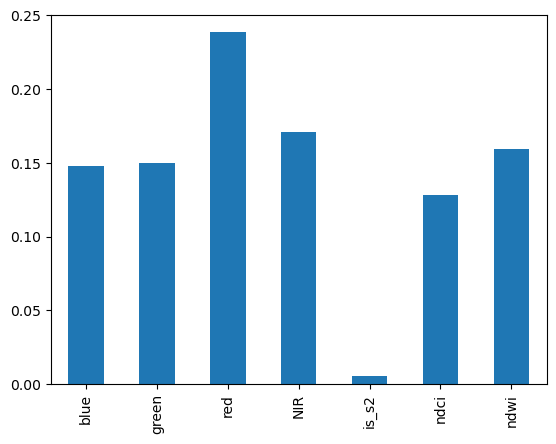

In [64]:
rf_feature_importances = pd.Series(rf.feature_importances_, index=features)

rf_feature_importances.plot.bar()

XGBoost

In [54]:
import xgboost as xgb

xgboost = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, max_depth=5, subsample=0.8, n_jobs=-1)
xgb_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('model', xgboost)])

xgb_r2 = cross_val_score(xgb_pipe, X_train, y_train, cv=kf, scoring='r2')
xgb_rmse = cross_val_score(xgb_pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print(f"R^2: {xgb_r2.mean():.4f} ± {xgb_r2.std():.4f}")
print(f"RMSE: {(-xgb_rmse).mean():.4f} ± {(-xgb_rmse).std():.4f}")

xgb_pipe.fit(X_train, y_train)
y_pred = xgb_pipe.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R^2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.3272 ± 0.0183
RMSE: 1.0584 ± 0.0196
R^2: 0.3301
RMSE: 1.0674


MLP Regressor

In [55]:
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

mlp = MLPRegressor(hidden_layer_sizes=(32, 32), activation='relu', max_iter=100)
mlp_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('model', mlp)])

mlp_r2 = cross_val_score(mlp_pipe, X_train, y_train, cv=kf, scoring='r2')
mlp_rmse = cross_val_score(mlp_pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print(f"R^2: {mlp_r2.mean():.4f} ± {mlp_r2.std():.4f}")
print(f"RMSE: {(-mlp_rmse).mean():.4f} ± {(-mlp_rmse).std():.4f}")

mlp_pipe.fit(X_train, y_train)
y_pred = mlp_pipe.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R^2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

/opt/anaconda3/envs/intro_to_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/intro_to_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/intro_to_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/anaconda3/envs/intro_to_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


R^2: 0.3260 ± 0.0175
RMSE: 1.0616 ± 0.0191
R^2: 0.3311
RMSE: 1.0667


/opt/anaconda3/envs/intro_to_ml/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


SVR

In [56]:
from sklearn.svm import SVR

svr = SVR(kernel='rbf', C=10, epsilon=0.1)
svr_pipe = Pipeline([('imputer', SimpleImputer(strategy='median')), ('scaler', StandardScaler()), ('model', svr)])

svr_r2 = cross_val_score(svr_pipe, X_train, y_train, cv=kf, scoring='r2')
svr_rmse = cross_val_score(svr_pipe, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')

print(f"R^2: {svr_r2.mean():.4f} ± {svr_r2.std():.4f}")
print(f"RMSE: {(-svr_rmse).mean():.4f} ± {(-svr_rmse).std():.4f}")

svr_pipe.fit(X_train, y_train)
y_pred = svr_pipe.predict(X_test)

r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"R^2: {r2:.4f}")
print(f"RMSE: {rmse:.4f}")

R^2: 0.2859 ± 0.0286
RMSE: 1.0903 ± 0.0285
R^2: 0.2979
RMSE: 1.0928
